In [62]:
!pip install -U segmentation-models

In [63]:
!pip install gradio

In [64]:
import os
import cv2
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt
import random

In [65]:
import os
os.environ["SM_FRAMEWORK"] = "tf.keras" # Tells segmentation_models to use tf.keras
import tensorflow as tf # Ensure tensorflow is imported first
import segmentation_models as sm

In [66]:
import tensorflow as tf
from keras.models import load_model

In [67]:
def jaccard_coef(y_true, y_pred):
  y_true_flatten = tf.keras.backend.flatten(y_true)
  y_pred_flatten = tf.keras.backend.flatten(y_pred)
  intersection = tf.keras.backend.sum(y_true_flatten * y_pred_flatten) # Fixed line
  final_coef_value = (intersection + 1.0) / (tf.keras.backend.sum(y_true_flatten) + tf.keras.backend.sum(y_pred_flatten) - intersection + 1.0) # Fixed line
  return final_coef_value

In [68]:
weights = [0.1666, 0.1666, 0.1666, 0.1666, 0.1666, 0.1666]
dice_loss = sm.losses.DiceLoss(class_weights = weights)
focal_loss = sm.losses.CategoricalFocalLoss()
total_loss = dice_loss + (1 * focal_loss)

In [69]:
metrics = [sm.metrics.IOUScore(threshold=0.5), sm.metrics.FScore(threshold=0.5), 'accuracy', jaccard_coef]
satellite_model = load_model('/content/satellite_segmentation_full.h5',
                         custom_objects=({'dice_loss_plus_1focal_loss': total_loss,
                                          'jaccard_coef': jaccard_coef}))
# Recompile the model after loading, as keract expects it to be compiled.
satellite_model.compile(optimizer="adam", loss=total_loss, metrics=metrics)
# Manually set _is_compiled to True for keract compatibility
satellite_model._is_compiled = True

In [70]:
image = Image.open('/content/img1.png')
image = image.resize((256,256))

# Explicitly convert the PIL Image object to RGB mode to ensure 3 channels
# This handles RGBA, L (grayscale), etc., and always yields 3 channels
image = image.convert('RGB')

image = np.array(image)
print(f"Image shape after opening, resizing, converting to RGB, and to numpy array: {image.shape}")

# This block acts as a fallback/redundancy for debugging, if PIL.convert('RGB') somehow fails
if image.shape[-1] == 4:
    image = image[:, :, :3] # Remove alpha channel if it somehow persists
    print(f"Image shape after fallback alpha channel removal: {image.shape}")
elif image.shape[-1] == 1:
    # Ensure cv2 is available, it is already imported in z4cq2KcugVq0
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB) # Fallback: convert grayscale to RGB
    print(f"Image shape after fallback grayscale to RGB conversion: {image.shape}")
elif image.shape[-1] != 3:
    print(f"Warning: Image has {image.shape[-1]} channels, but model expects 3. Proceeding with current channels.")

image = np.expand_dims(image, 0)
print(f"Final image shape before prediction/activations: {image.shape}")

Image shape after opening, resizing, converting to RGB, and to numpy array: (256, 256, 3)
Final image shape before prediction/activations: (1, 256, 256, 3)


In [71]:
prediction = satellite_model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step


In [72]:
predicted_image = np.argmax(prediction, axis=3)
predicted_image = predicted_image[0,:,:]

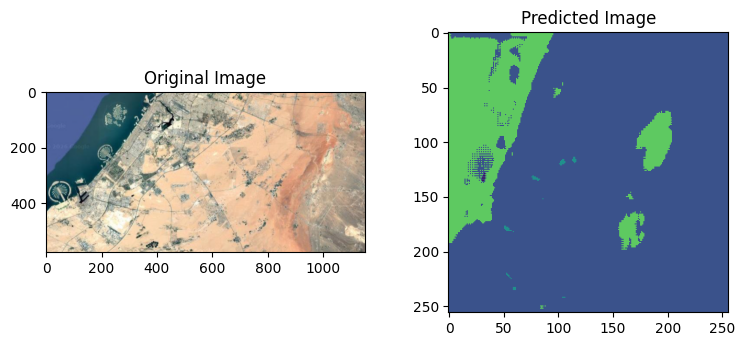

In [73]:
plt.figure(figsize=(14,8))
plt.subplot(231)
plt.title("Original Image")
plt.imshow(Image.open('/content/img1.png'))
plt.subplot(232)
plt.title("Predicted Image")
plt.imshow(predicted_image)

In [74]:
import gradio as gr

In [75]:
my_app = gr.Blocks()

In [76]:
import cv2

def process_input_image(image_source):
  # Convert image_source (numpy array from Gradio) to PIL Image for resizing
  image_pil = Image.fromarray(image_source.astype('uint8'))
  image_pil = image_pil.resize((256, 256))
  image_pil = image_pil.convert('RGB')

  image_np = np.array(image_pil)
  image = np.expand_dims(image_np, 0)

  prediction = satellite_model.predict(image)
  predicted_image = np.argmax(prediction, axis=3)

  predicted_image = predicted_image[0,:,:]
  predicted_image = predicted_image * 50
  return 'Predicted Masked Image', predicted_image

with my_app:
  gr.Markdown("Statellite Image Segmentation Application UI with Gradio")
  with gr.Tabs():
    with gr.TabItem("Select your image"):
      with gr.Row():
        with gr.Column():
            img_source = gr.Image(label="Please select source Image")
            source_image_loader = gr.Button("Load above Image")
        with gr.Column():
            output_label = gr.Label(label="Image Info")
            img_output = gr.Image(label="Image Output")
    source_image_loader.click(
        process_input_image,
        [
            img_source
        ],
        [
            output_label,
            img_output
        ]
    )

In [77]:
my_app.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c1a7b8daa7b174360d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://c1a7b8daa7b174360d.gradio.live
